<a href="https://colab.research.google.com/github/logankim0913/EE_467_Final_Project/blob/main/phase1and2_allbenigntraffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data
Loading data from the Benign/Dictionary Brute Force/DNS_Spoofing dataset. Since the CIC IoT Intrusion dataset for benign traffic comes with a number of batches of data, which we are using to train our autoencoder, we can simply designate some of them for training and the other for testing instead of spliting up a single dataset. This is done under the assumption that these benign traffic datasets are independent from each other; training the autoencoder with one of them should not "leak" any information about the test benign traffic dataset.

In [62]:
import pandas as pd

# scaling only on benign data
bfd = pd.read_csv("DictionaryBruteForce.pcap.csv")
spoof = pd.read_csv("DNS_Spoofing.pcap.csv")
benign = pd.read_csv("BenignTraffic.pcap.csv")
benign1 = pd.read_csv("BenignTraffic1.pcap.csv")
benign2 = pd.read_csv("BenignTraffic2.pcap.csv")
benign3 = pd.read_csv("BenignTraffic3.pcap.csv")

# use different datasets for train/val/test benign
train_benign = pd.concat([benign, benign1])
val_benign = benign2
test_benign = benign3

# Establish the seed for any random_state functions later open
RANDOM_SEED = 42

## Preprocessing - Drop problematic features
Because we see that features like `Rate` has unprocessable values, we will remove that feature for preprocessing step later.

In [63]:
import numpy as np

def clean_df(df):
    #Replaces inf/-inf with NaN and drops those selected rows
    return df.replace([np.inf, -np.inf], np.nan).dropna()

# handle infinite values before scaling drop rows with infinity
bfd = clean_df(bfd)
spoof = clean_df(spoof)
benign_train = clean_df(train_benign)
benign_val = clean_df(val_benign)
benign_test = clean_df(test_benign)

## Preprocessing
### Standard Scaling

One of the feature scaling methods we are exploring is `StandardScaler()`. If the features have not much effects from outliers, it will scale the values normally.

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#training set for benign
X_train = scaler.fit_transform(benign_train[benign_train.columns].values) # Assuming benign_train has all the relevant columns
#validation set for benign
X_val_benign = scaler.transform(benign_val[benign_train.columns].values)

# test set includes benign_test + all attacks
test = pd.concat(
    [
        benign_test.assign(label=0),   # 0 = benign
        bfd.assign(label=1),           # 1 = attack
        spoof.assign(label=1),
    ],
    ignore_index=True
)

#test set has both benign and attack
X_test = scaler.transform(test[bfd.columns].values)
#labels for test set
y_test = test["label"].values

print("Shapes:")
print("X_train (benign):", X_train.shape)
print("X_val_benign:", X_val_benign.shape)
print("X_test (mixed):", X_test.shape, "y_test:", y_test.shape)

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())

Shapes:
X_train (benign): (657907, 39)
X_val_benign: (310395, 39)
X_test (mixed): (321781, 39) y_test: (321781,)

Test class balance:
1    191957
0    129824
Name: count, dtype: int64


### Robust Scaling

We also implement the `Robust Scaling` to remove potential outliers present in our original benign traffic dataset.

In [ ]:
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
# training set for benign
X_train_robust = rscaler.fit_transform(benign_train[benign_train.columns].values) # Assuming benign_train has all the relevant columns
# validation set for benign
X_val_benign_robust = rscaler.transform(benign_val[benign_train.columns].values)

# test set has both benign and attack
X_test_robust = rscaler.transform(test[bfd.columns].values)
#labels for test set
y_test_robust = test["label"].values

# Shapes should be the same as post-StandardScaling
print("Shapes:")
print("X_train (benign):", X_train_robust.shape)
print("X_val_benign:", X_val_benign_robust.shape)
print("X_test (mixed):", X_test_robust.shape, "y_test:", y_test_robust.shape)

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())

Shapes:
X_train (benign): (657907, 39)
X_val_benign: (310395, 39)
X_test (mixed): (321781, 39) y_test: (321781,)

Test class balance:
1    191957
0    129824
Name: count, dtype: int64


## Autoencoder Design

After data features are scaled properly, we define the structure of the autoencoder that will be used as a classifier to detect IoT attacks.

In [66]:
from tensorflow import keras
from tensorflow.keras import layers

#Built autoencoder
def build_autoencoder(input_dim):

    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    latent = layers.Dense(8, activation='relu')(x)

    # Decoder
    x = layers.Dense(16, activation='relu')(latent)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(input_dim)(x)

    model = keras.Model(inputs, outputs)

    encoder = keras.Model(inputs, latent)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model, encoder

And just instantiate the defined autoencoder. We will have one for standard scaled features and one for robust scaled ones.

In [69]:
#instantiate model
ae, encoder = build_autoencoder(X_train.shape[1])
ae_robust, encoder_robust = build_autoencoder(X_train_robust.shape[1])


#parameter count
def count_parameters(model):
    return np.sum([np.prod(v.shape) for v in model.trainable_weights])

print("Trainable Parameters:", count_parameters(ae))

Trainable Parameters: 3919


## Training the autoencoders

Now that the structure of our autoencoder is defined, we should train it with *only the benign traffic dataset* to ensure that it is **ONLY** optimized to represent the benign traffic datasets and nothing else. The *Gaussian noise* is added to introduce some variability in the training samples so that the autoencoder becomes more robust.

In [70]:
# Train autoencoder
import numpy as np

def add_gaussian_noise(X, sigma=0.05):
    Xn = X + np.random.normal(0.0, sigma, size=X.shape)
    return Xn

sigma = 0.05  # try 0.02, 0.05, 0.1
X_train_noisy = add_gaussian_noise(X_train, sigma=sigma)
X_train_robust_noisy = add_gaussian_noise(X_train_robust, sigma=sigma)

history = ae.fit(
    X_train_noisy, X_train,          # noisy input, clean target
    validation_data=(X_val_benign, X_val_benign),
    epochs=40,
    batch_size=512,
    verbose=1
)

history_robust = ae_robust.fit(
    X_train_robust_noisy, X_train_robust,          # noisy input, clean target
    validation_data=(X_val_benign_robust, X_val_benign_robust),
    epochs=40,
    batch_size=512,
    verbose=1
)

# history = ae.fit(
#     X_train,
#     X_train,
#     epochs=40,
#     batch_size=256,
#     validation_data=(X_val_benign, X_val_benign),
#     verbose=1
# )

Epoch 1/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2895 - val_loss: 0.1077
Epoch 2/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0930 - val_loss: 0.0587
Epoch 3/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0653 - val_loss: 0.0466
Epoch 4/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0575 - val_loss: 0.0431
Epoch 5/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0536 - val_loss: 0.0394
Epoch 6/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0504 - val_loss: 0.0380
Epoch 7/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0479 - val_loss: 0.0357
Epoch 8/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0457 - val_loss: 0.0337
Epoch 9/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0439 - val_loss: 0.0327
Epoch 10/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0418 - val_loss: 0.0305
Epoch 11/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0386 - val_loss: 0.0272
Epoch 12/40
1285/1285 ━━━━━━━━

In [57]:
# Reconstruction error
def reconstruction_error(model, X):
    reconstructed = model.predict(X, verbose=0)
    error = np.mean((X - reconstructed) ** 2, axis=1)
    return error

In [77]:
# Threshold at 0.5% FPR
def compute_threshold(val_errors, target_fpr=0.005):
    return np.percentile(val_errors, 100 * (1 - target_fpr))

val_errors = reconstruction_error(ae, X_val_benign)
threshold = compute_threshold(val_errors, 0.005)

print("0.5% FPR Threshold:", threshold)

0.5% FPR Threshold: 0.31772049932653285


In [76]:
# AE detection on test set
def ae_predict(model, X, threshold):
    errors = reconstruction_error(model, X)
    preds = (errors > threshold).astype(int)
    return preds, errors

ae_preds, ae_errors = ae_predict(ae, X_test, threshold)
ae_robust_preds, ae_robust_errors = ae_predict(ae_robust, X_test, threshold)

## Create baseline models for performance comparison

We are also creating other baseline classifiers to see how our autoencoder classifier's performance is compared to other types of classifiers. Here, we are creating `LogisticRegression()` model for classification. Unlike autoencoder which requires only the benign traffic for its training, you need labeled datasets for both benign and attacks since Logistic Regression is a supervised classifier.

In [78]:
def count_lr_params(model):
  # Coefficients (one per feature per class, but binary only needs one set)
  n_coefficients = model.coef_.size

  # Intercepts (one per class, binary only needs one)
  n_intercepts = model.intercept_.size

  total_params = n_coefficients + n_intercepts
  print(f"Total parameters: {total_params}")


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

bfd_train, bfd_test = train_test_split(
    bfd, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
spoof_train, spoof_test = train_test_split(
    spoof, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)

train_full = pd.concat(
    [
        benign_train.assign(label=0),
        bfd_train.assign(label=1),
        spoof_train.assign(label=1),
    ]
)

test = pd.concat(
    [
        benign_test.assign(label=0),
        bfd_test.assign(label=1),
        spoof_test.assign(label=1),
    ],
    ignore_index=True
)


X_train_full = scaler.transform(train_full[bfd.columns].values)
y_train_full = train_full["label"].values


#Logistic Regression baseline
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train_full, y_train_full)
lr_preds = logreg.predict(X_test)
count_lr_params(logreg)

c:\Users\logan\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Total parameters: 40


In [80]:
#Autoencoder Evaluation (Standard Scaling)
from sklearn.metrics import classification_report
tn, fp, fn, tp = confusion_matrix(y_test, ae_preds).ravel()

ae_recall = tp / (tp + fn)
ae_fpr = fp / (fp + tn)

#Autoencoder Evaluation (Robust Scaling)
tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test_robust, ae_robust_preds).ravel()

ae_robust_recall = tp_r / (tp_r + fn_r)
ae_robust_fpr = fp_r / (fp_r + tn_r)

#Logistic Regression Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, lr_preds).ravel()

lr_recall = tp / (tp + fn)
lr_fpr = fp / (fp + tn)

print("AE (Standard) Recall @ 0.5% FPR:", ae_recall)
print("AE (Standard) Actual FPR:", ae_fpr, "\n")

print("AE (Robust) Recall @ 0.5% FPR:", ae_robust_recall)
print("AE (Robust) Actual FPR:", ae_robust_fpr, "\n")

print("AE (Standard) Classification Report: \n\n", classification_report(y_test, ae_preds))
print("\nAE (Robust) Classification Report: \n\n", classification_report(y_test_robust, ae_robust_preds))
print("\nLogistic Regression Classification Report: \n\n", classification_report(y_test, lr_preds))

print("LogReg Recall:", lr_recall)
print("LogReg FPR:", lr_fpr, "\n")

AE (Standard) Recall @ 0.5% FPR: 0.06292555103486719
AE (Standard) Actual FPR: 0.006262324377618931 

AE (Robust) Recall @ 0.5% FPR: 0.395364586860599
AE (Robust) Actual FPR: 0.20129560019719003 

AE (Standard) Classification Report: 

               precision    recall  f1-score   support

           0       0.42      0.99      0.59    129824
           1       0.94      0.06      0.12    191957

    accuracy                           0.44    321781
   macro avg       0.68      0.53      0.35    321781
weighted avg       0.73      0.44      0.31    321781


AE (Robust) Classification Report: 

               precision    recall  f1-score   support

           0       0.47      0.80      0.59    129824
           1       0.74      0.40      0.52    191957

    accuracy                           0.56    321781
   macro avg       0.61      0.60      0.55    321781
weighted avg       0.63      0.56      0.55    321781


Logistic Regression Classification Report: 

               precision

In [81]:
def distance_scoring(encoder, kmeans, X):
  latent = encoder.predict(X, verbose=0)
  distances = kmeans.transform(latent)
  min_distances = distances.min(axis=1)
  return min_distances

def ae_kmeans_predict(encoder, kmeans, X, threshold):
    distances = distance_scoring(encoder, kmeans, X)
    preds = (distances > threshold).astype(int)
    return preds, distances

In [82]:
from sklearn.cluster import MiniBatchKMeans, KMeans
latent_train = encoder.predict(X_train)
kmeans = KMeans(random_state=0, max_iter=500)
kmeans.fit(latent_train)

distances = distance_scoring(encoder, kmeans, X_val_benign)
scoring_threshold = np.percentile(distances, 99.5)

ae_km_preds, ae_km_distances = ae_kmeans_predict(encoder, kmeans, X_test, scoring_threshold)

20560/20560 ━━━━━━━━━━━━━━━━━━━━ 11s 541us/step


In [44]:
tn, fp, fn, tp = confusion_matrix(y_test, ae_km_preds).ravel()

ae_k_recall = tp / (tp + fn)
ae_k_fpr = fp / (fp + tn)

print("AE K-means Recall @ 0.5% FPR:", ae_k_recall)
print("AE K-Means Actual FPR:", ae_k_fpr, "\n")

print("AE Classification Report: \n\n", classification_report(y_test, ae_km_preds))

AE K-means Recall @ 0.5% FPR: 0.03054850825966232
AE K-Means Actual FPR: 0.0075794922356421 

AE Classification Report: 

               precision    recall  f1-score   support

           0       0.41      0.99      0.58    129824
           1       0.86      0.03      0.06    191957

    accuracy                           0.42    321781
   macro avg       0.63      0.51      0.32    321781
weighted avg       0.68      0.42      0.27    321781



In [45]:
def count_rf_params(model):
    total_nodes = sum(tree.tree_.node_count for tree in model.estimators_)

    print(f"Number of trees: {len(model.estimators_)}")
    print(f"Total nodes: {total_nodes}")

In [46]:
from sklearn.ensemble import RandomForestClassifier
N_ENSEMBLE_CPUS = max(os.cpu_count()//2, 1)
rf_15_model = RandomForestClassifier(n_estimators=15, n_jobs=N_ENSEMBLE_CPUS).fit(X_train_full, y_train_full)
rf_15_preds = rf_15_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, rf_15_preds).ravel()

rf_recall = tp / (tp + fn)
rf_fpr = fp / (fp + tn)

print("\nRF Classification Report: \n\n", classification_report(y_test, rf_15_preds))

print("RF 15 Recall:", rf_recall)
print("RF 15 FPR:", rf_fpr, "\n")

print("Random Forest Classifier Model Features:")
count_rf_params(rf_15_model)



RF Classification Report: 

               precision    recall  f1-score   support

           0       0.92      0.99      0.95    129824
           1       1.00      0.94      0.97    191957

    accuracy                           0.96    321781
   macro avg       0.96      0.97      0.96    321781
weighted avg       0.96      0.96      0.96    321781

RF 15 Recall: 0.9376474939700037
RF 15 FPR: 0.006870840522553611 

Random Forest Classifier Model Features:
Number of trees: 15
Total nodes: 920955


## Overall Metrics Report

Here is the table that helps comparing the Autoencoder-based IoT attack classifier to other baseline models.

Autoencoder F1: 0.1179
AE+KMeans F1: 0.0542
LogReg F1: 0.8026
RF-15 F1: 0.9655


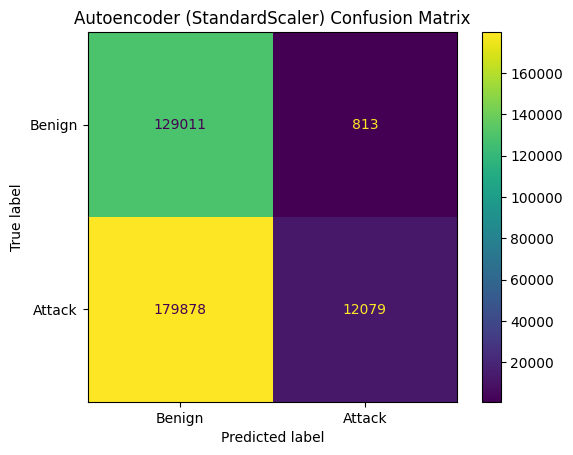

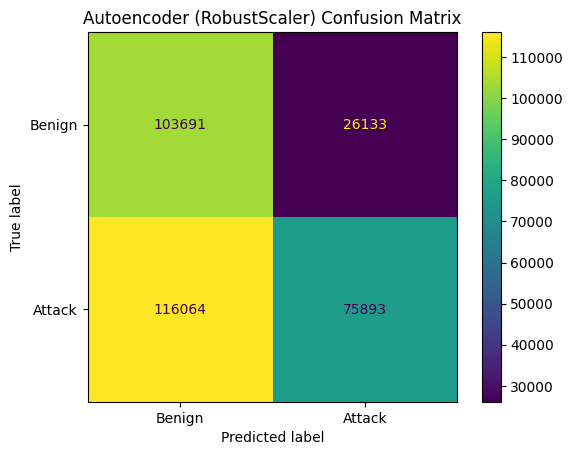

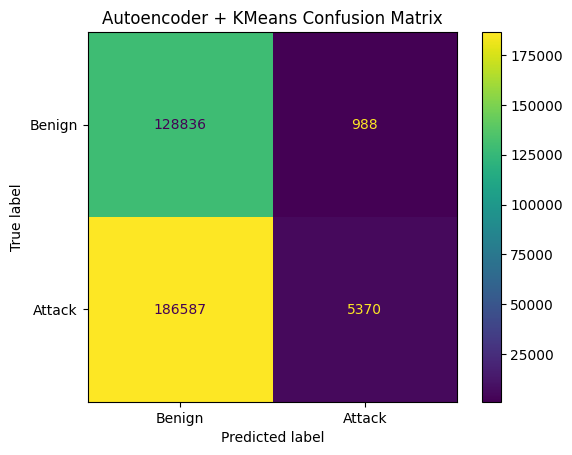

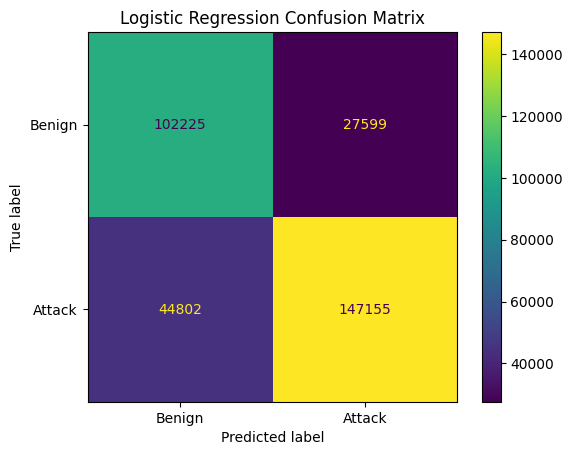

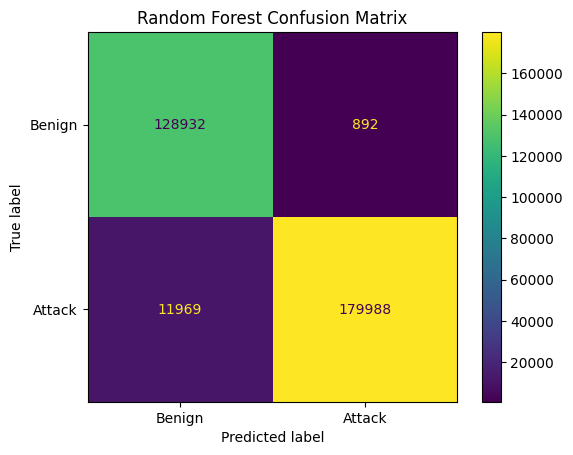

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

# --- Autoencoder (StandardScaler) ---
show_cm(
    y_test,
    ae_preds,
    "Autoencoder (StandardScaler) Confusion Matrix"
)

# --- Autoencoder (RobustScaler) ---
show_cm(
    y_test_robust,
    ae_robust_preds,
    "Autoencoder (RobustScaler) Confusion Matrix"
)

# --- AE + KMeans ---
show_cm(
    y_test,
    ae_km_preds,
    "Autoencoder + KMeans Confusion Matrix"
)

# --- Logistic Regression ---
show_cm(
    y_test,
    lr_preds,
    "Logistic Regression Confusion Matrix"
)

# --- Random Forest ---
show_cm(
    y_test,
    rf_15_preds,
    "Random Forest Confusion Matrix"
)